# Eksperimen — Pima Indians Diabetes
**Nama:** Iqbal Raihan  
Notebook eksperimen preprocessing sesuai template MSML: **Data Loading → EDA → Preprocessing**.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


## 2. Data Loading

In [2]:
df = pd.read_csv('../diabetes_raw.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistik deskriptif

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 3.2 Distribusi target

Outcome
0    500
1    268
Name: count, dtype: int64


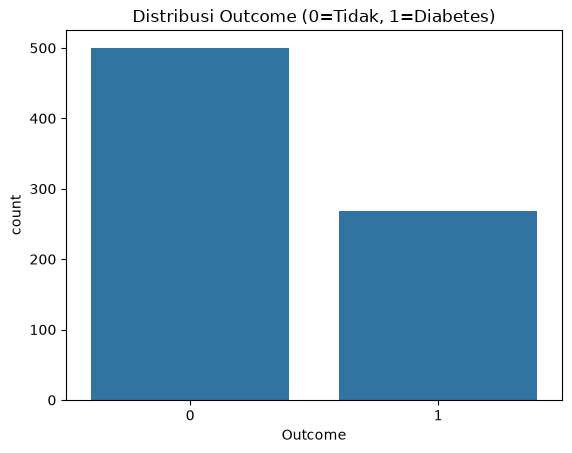

In [5]:
print(df['Outcome'].value_counts())
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Outcome (0=Tidak, 1=Diabetes)')
plt.show()

### 3.3 Deteksi nilai tidak valid
Beberapa kolom medis tidak mungkin bernilai 0 (mis. Glucose, BloodPressure, BMI).
Nilai 0 di kolom-kolom ini sebenarnya **missing value** yang tersamar.

In [6]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_cols:
    n = (df[col] == 0).sum()
    print(f'{col}: {n} nilai 0 ({n/len(df)*100:.1f}%)')

Glucose: 5 nilai 0 (0.7%)
BloodPressure: 35 nilai 0 (4.6%)
SkinThickness: 227 nilai 0 (29.6%)
Insulin: 374 nilai 0 (48.7%)
BMI: 11 nilai 0 (1.4%)


### 3.4 Korelasi antar fitur

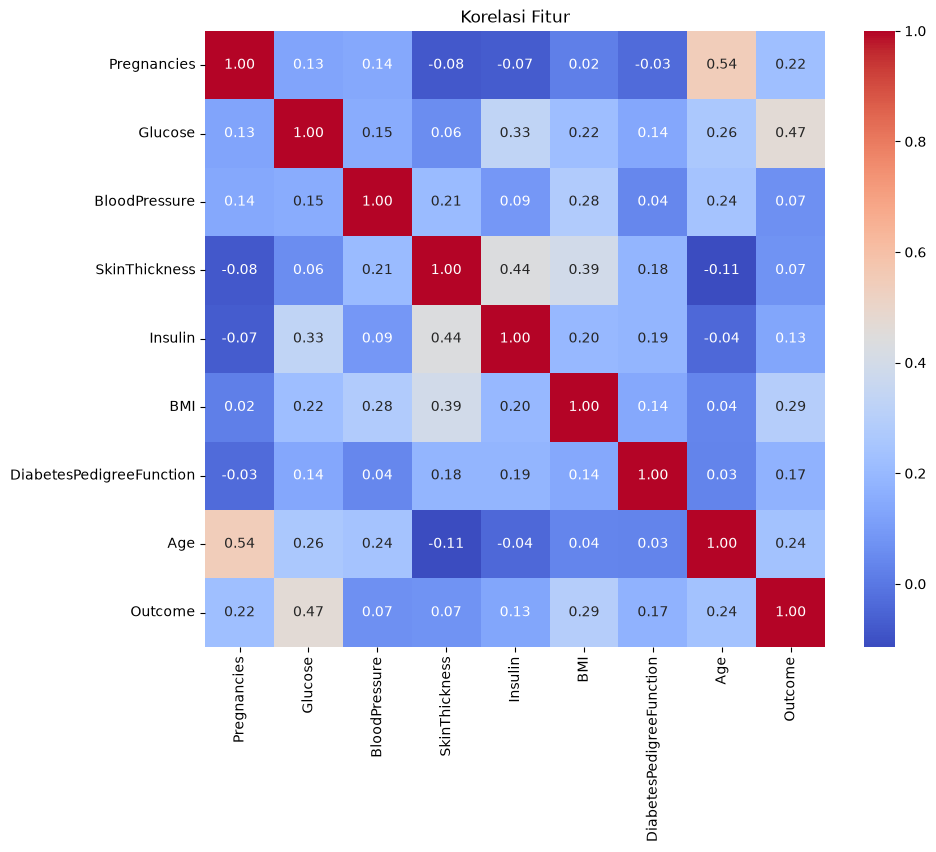

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Fitur')
plt.show()

### 3.5 Distribusi fitur

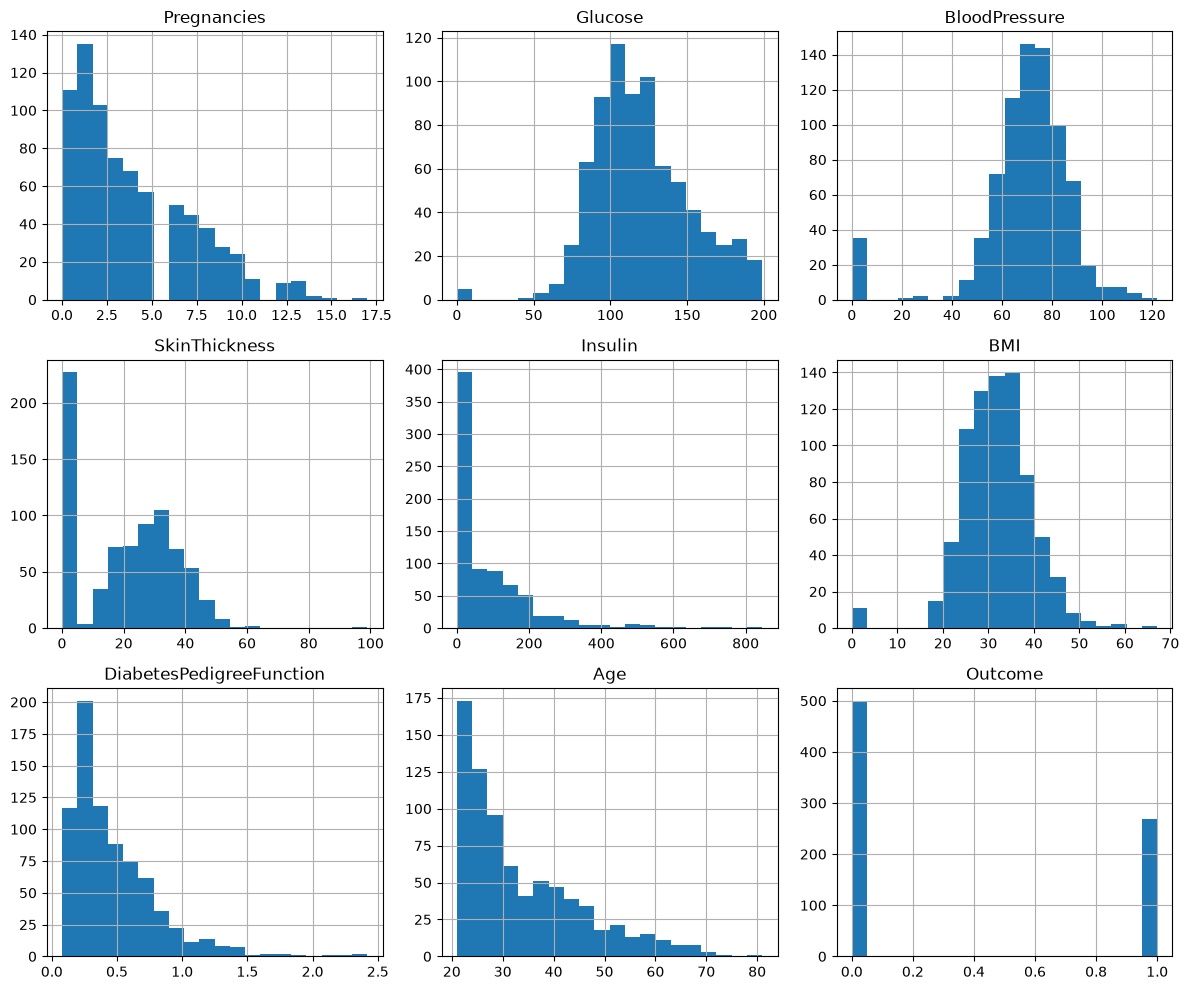

In [8]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

## 4. Preprocessing
Langkah: (1) ganti 0 tidak valid dengan median, (2) split train-test, (3) standardisasi.

### 4.1 Handling missing value tersamar

In [9]:
df_clean = df.copy()
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Sisa nilai 0 setelah cleaning:')
for col in zero_cols:
    print(f'  {col}: {(df_clean[col]==0).sum()}')

Sisa nilai 0 setelah cleaning:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0


### 4.2 Split fitur & target

In [10]:
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (614, 8) | Test: (154, 8)


### 4.3 Standardisasi fitur

In [11]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X.columns, index=X_test.index
)
X_train_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02
mean,-6.943414e-17,-1.099374e-16,3.095606e-16,-3.471707e-17,-4.339634e-18,-1.148556e-15,-1.099374e-16,-1.084908e-16
std,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00
min,-1.153338e+00,-2.190541e+00,-3.924957e+00,-2.480958e+00,-1.559139e+00,-2.089399e+00,-1.192094e+00,-1.045895e+00
25%,-8.513551e-01,-7.562208e-01,-6.636760e-01,-4.549828e-01,-2.249692e-01,-7.071473e-01,-7.042617e-01,-7.921693e-01
50%,-2.473897e-01,-1.558076e-01,-1.141979e-02,-4.766137e-03,-1.614373e-01,-2.152099e-02,-2.876344e-01,-3.692933e-01
75%,6.585583e-01,6.113872e-01,6.408364e-01,3.328964e-01,-9.790537e-02,5.944428e-01,4.903223e-01,6.456090e-01
max,3.980368e+00,2.579408e+00,4.065181e+00,7.874025e+00,7.703814e+00,5.082179e+00,5.610293e+00,4.028617e+00


### 4.4 Simpan hasil preprocessing

In [12]:
import os
os.makedirs('diabetes_preprocessing', exist_ok=True)

train_out = X_train_scaled.copy(); train_out['Outcome'] = y_train.values
test_out  = X_test_scaled.copy();  test_out['Outcome']  = y_test.values

train_out.to_csv('diabetes_preprocessing/diabetes_train.csv', index=False)
test_out.to_csv('diabetes_preprocessing/diabetes_test.csv', index=False)
print('Tersimpan: diabetes_train.csv & diabetes_test.csv')

Tersimpan: diabetes_train.csv & diabetes_test.csv


## 5. Kesimpulan
- Data 768 baris, 8 fitur numerik, target biner (65% non-diabetes / 35% diabetes).
- Ditemukan nilai 0 tidak valid pada 5 kolom medis → di-impute dengan median.
- Data di-split 80:20 (stratified) dan distandardisasi.
- Hasil siap dilatih; langkah ini dikonversi ke `automate_Iqbal-Raihan.py`.